# Naive Bayes

## Imports

In [ ]:
import pandas as pd
import numpy as np
import joblib
import time
import joblib

import matplotlib.pyplot as plt

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
tfidf = joblib.load("/content/tfidf_vectorizer.pkl")

x_train = joblib.load("/content/x_train.pkl")
x_test = joblib.load("/content/x_test.pkl")

y_train = joblib.load("/content/y_train.pkl")
y_test = joblib.load("/content/y_test.pkl")

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1274150,)
(318538,)
(1274150,)
(318538,)


In [ ]:
x_train_tf = tfidf.transform(x_train)
x_test_tf = tfidf.transform(x_test)

In [ ]:
print(x_train_tf.shape)
print(x_test_tf.shape)

(1274150, 50000)
(318538, 50000)


## Model

In [ ]:
# MultinomialNB(
#     alpha=1.0,         # Laplace smoothing
#     fit_prior=True,    # Learn class priors from the data
#     class_prior=None,  # Use learned priors
#     force_alpha=True   # Keep alpha exactly as specified
# )

In [ ]:
model_nb = MultinomialNB(
    alpha=0.5,
    fit_prior=True,
    force_alpha=True
)

In [ ]:
start = time.time()
model_nb.fit(x_train_tf, y_train)
end = time.time()

print(f"Training Time: {end-start:.2f} Seconds")

Training Time: 0.47 Seconds


In [ ]:
start = time.time()
y_pred = model_nb.predict(x_test_tf)
end = time.time()

print(f"Prediction Time: {end-start:.2f} Seconds")

Prediction Time: 0.10 Seconds


In [ ]:
y_prob = model_nb.predict_proba(x_test_tf)[:, 1]
print(y_prob)

[0.54817049 0.06469533 0.34074515 ... 0.2089416  0.17129996 0.54538567]


In [ ]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7783
Precision: 0.7758
Recall   : 0.7828
F1 Score : 0.7793
ROC AUC  : 0.8599


In [ ]:
# Classification Report
print(f"Classification_Report: \n \n {classification_report(y_test, y_pred)}")

Classification_Report: 
 
               precision    recall  f1-score   support

           0       0.78      0.77      0.78    159267
           1       0.78      0.78      0.78    159271

    accuracy                           0.78    318538
   macro avg       0.78      0.78      0.78    318538
weighted avg       0.78      0.78      0.78    318538



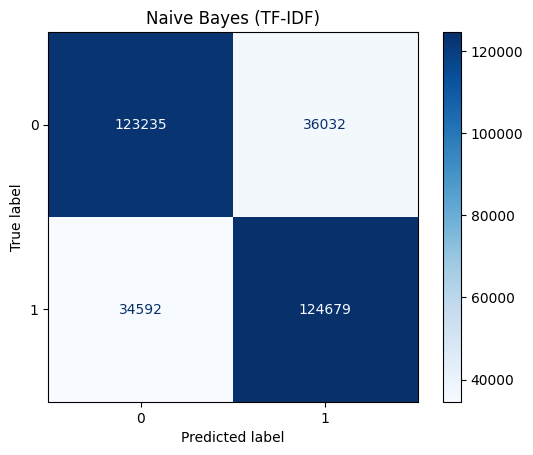

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap = "Blues"
)

plt.title("Naive Bayes (TF-IDF)")
plt.show()

In [ ]:
joblib.dump(model_nb, "nb_model.pkl")

['nb_model.pkl']